In [2]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

%load_ext autoreload 
%autoreload 2
%matplotlib inline


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
from meteor.tv import tv_denoise_difference_map
from meteor.validate import map_negentropy

In [4]:
# from photolyase import *
from photolyase import get_exp_structure_factors, calculate_dog_filter_mask_v2, ccp4_to_mask
from compare_conds import get_intersect_and_angle
from photolyase import get_hists, plot_hists, find_wasserstein_dip
from plotting3d import slice_3d, add_fit
from meteorize import *
# from output_eval import panels_3d



In [5]:
folderloc =  homepath+'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
changing_bit = "6_10ns/10ns"
changing_bit = "2_3ps/3ps"
changing_bit = "3_300ps/300ps"
changing_bit = "7_30ns/30ns"
dataloc_light = folderloc + changing_bit + "_deposit.mtz"
pdbloc_light  = folderloc + changing_bit + '_deposit.pdb'


mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 2.4 
map_sampling = 3




In [35]:
!ls $folderloc

10_30us                        6_10ns
11_100us                       7_30ns
1_superdark                    8_1us
2_3ps                          9_10us
3_300ps                        low_pump_power_difference_maps
4_1ns                          readme.txt
5_3ns                          restraints


# Data Preparation

## Obtaining F and rho from real data

In [6]:
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)

ds_light

IMEAN       SIGIMEAN           F       SIGF       KFEXTR  \
H  K L                                                                   
0  0 2          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
     6   563041.625  124030.234375  733.373047  87.899185  3107.084473   
     7 -1661.612183    1027.905151    12.38824   8.876429          NaN   
     8  -470.827209     346.035034    7.571723   5.376757    58.114021   
...             ...            ...         ...        ...          ...   
29 5 5          NaN            NaN         NaN        NaN          NaN   
   6 0          NaN            NaN         NaN        NaN          NaN   
     1          NaN            NaN         NaN        NaN          NaN   
     2          NaN            NaN         NaN        NaN          NaN   
     3          NaN            NaN         NaN        NaN          NaN   

        SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H  K L                                                                  
0  0 2        NaN           NaN          NaN         NaN  6650.478516   
     4        NaN            14          NaN         NaN  1927.483765   
     6  16.496628             6  3358.235596         0.0  3301.962158   
     7        NaN           NaN          NaN         NaN          NaN   
     8  40.554333            17   168.217529         0.0     2.425961   
...           ...           ...          ...         ...          ...   
29 5 5        NaN             3          NaN         NaN          NaN   
   6 0        NaN            10          NaN         NaN          NaN   
     1        NaN             8          NaN         NaN          NaN   
     2        NaN            19          NaN         NaN          NaN   
     3        NaN            13          NaN         NaN          NaN   

        PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K L                                                                       
0  0 2        0.0              NaN                NaN         NaN       NaN  
     4        0.0              NaN                NaN         NaN       NaN  
     6        0.0      3301.962158                0.0  752.040527       0.0  
     7        NaN              NaN                NaN         NaN       NaN  
     8        0.0         2.425961                0.0  124.879761     180.0  
...           ...              ...                ...         ...       ...  
29 5 5        NaN              NaN                NaN         NaN       NaN  
   6 0        NaN              NaN                NaN         NaN       NaN  
     1        NaN              NaN                NaN         NaN       NaN  
     2        NaN              NaN                NaN         NaN       NaN  
     3        NaN              NaN                NaN         NaN       NaN  

[56146 rows x 15 columns]

In [7]:
map_dark, map_light = get_scaled_maps(ds_dark, ds_light)



Index(['I-obs', 'SIGI-obs', 'R-free-flags', 'F-obs-filtered',
       'SIGF-obs-filtered', 'F-model', 'PHIF-model', '2FOFCWT', 'PH2FOFCWT',
       '2FOFCWT_no_fill', 'PH2FOFCWT_no_fill', 'FOFCWT', 'PHFOFCWT'],
      dtype='object')
F-obs-filtered
cols here Index(['F_dark', 'SIGF_dark', 'F_light', 'SIGF_light'], dtype='object')
Running scaleit, see tmp/launch_scaleit.sh
cols Index(['F_dark', 'SIGF_dark', 'F_light', 'SIGF_light'], dtype='object')


./tmp/launch_scaleit.sh: line 2: scaleit: command not found


In [8]:
from photolyase import loading_diffmaps
diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    changing_bit=changing_bit,
    map_sampling=map_sampling,
)

key = "tv"
diffmap = diffmaps[key]


Reading from photolyase30ns.mtz


In [9]:
from photolyase import load_masks,load_mask_config
mask_configs = load_mask_config(
        diffmap,
        map_sampling,
        mask_loc_sphere,
        mask_loc_handcraft
)
masks = load_masks(diffmap,map_sampling, mask_configs)

extrapolation_factors = np.arange(1,100,2.5)
map_xtrs = make_k_space_xtr(map_dark, diffmap, extrapolation_factors)

dogged
0.0006287442985922098 {424: 182, 90: 182, 91: 182, 87: 182, 86: 182, 210: 181, 345: 182, 206: 181, 15: 96, 346: 182, 109: 166, 116: 125, 359: 163, 412: 163, 115: 125, 189: 164, 110: 166, 180: 154, 358: 163, 531: 70, 527: 70, 532: 70, 528: 70}
0.0006702066166326404 {415: 176, 416: 176, 267: 80, 104: 80, 563: 80, 564: 80, 271: 80, 574: 80, 114: 80, 573: 80, 115: 80, 105: 80, 471: 80, 12: 80, 408: 177, 176: 175, 177: 175, 379: 80, 192: 52, 377: 80, 197: 77, 133: 86, 149: 176, 430: 78, 2: 60, 196: 77, 257: 87, 1: 60, 433: 78, 258: 87, 461: 91, 462: 91, 395: 92}


In [10]:
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold = 0.4)



### Plotting the  blobs

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

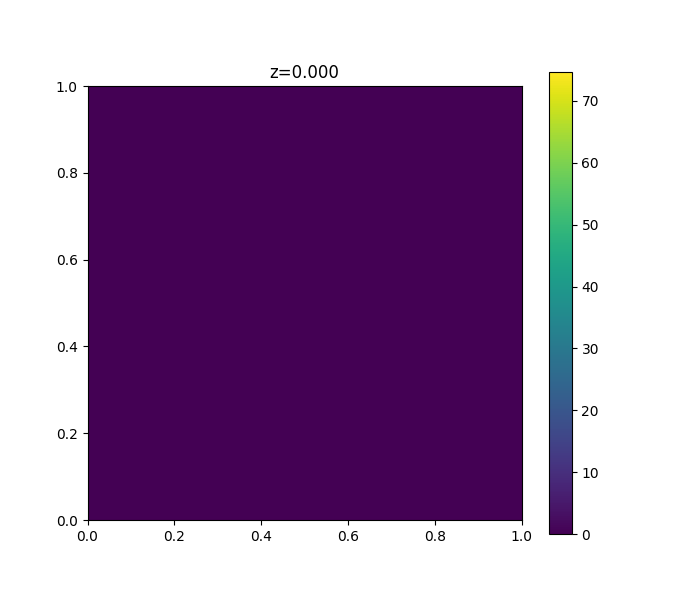

In [11]:
# pos_blobs_summed  = np.sum(np.asarray(pos_blobs,int), axis=0)
pb_max = pos_blobs.max()
pos_blobs_inv = pb_max - pos_blobs
pos_blobs_inv[pos_blobs_inv==pb_max] = 0  # set background to 0
# neg_blobs[neg_blobs>20] = 0 
nb_max = neg_blobs.max()
neg_blobs_inv = nb_max - neg_blobs
neg_blobs_inv[neg_blobs_inv==nb_max] = 0  # set background to 0
# _ = slice_3d(pos_blobs_inv)
%matplotlib widget
_ = slice_3d(np.array(neg_blobs,int)+np.max(neg_blobs)/3*masks["handpicked"], imkwargs={'vmax':np.max(neg_blobs)*4/3, 'vmin':0})


# Many Negative Sum Explosions

running  0.2
601
Intersection Average: 36.41 ± 12.14
Intersection Average Inverse: 0.06 ± 0.02
running  0.25
371
Intersection Average: 31.18 ± 14.65
Intersection Average Inverse: 0.08 ± 0.03
running  0.3
157
Intersection Average: 28.01 ± 14.24
Intersection Average Inverse: 0.09 ± 0.03
running  0.35
99
Intersection Average: 28.71 ± 14.48
Intersection Average Inverse: 0.09 ± 0.03
running  0.39999999999999997
56
Intersection Average: 26.36 ± 12.11
Intersection Average Inverse: 0.09 ± 0.03
running  0.44999999999999996
23
Intersection Average: 26.11 ± 10.16
Intersection Average Inverse: 0.09 ± 0.03
running  0.49999999999999994
15
Intersection Average: 23.78 ± 9.22
Intersection Average Inverse: 0.10 ± 0.04
running  0.5499999999999999
15
Intersection Average: 24.20 ± 11.85
Intersection Average Inverse: 0.10 ± 0.04
running  0.5999999999999999
10
Intersection Average: 22.37 ± 11.03
Intersection Average Inverse: 0.11 ± 0.04
running  0.6499999999999999
10
Intersection Average: 23.81 ± 11.07
Inter

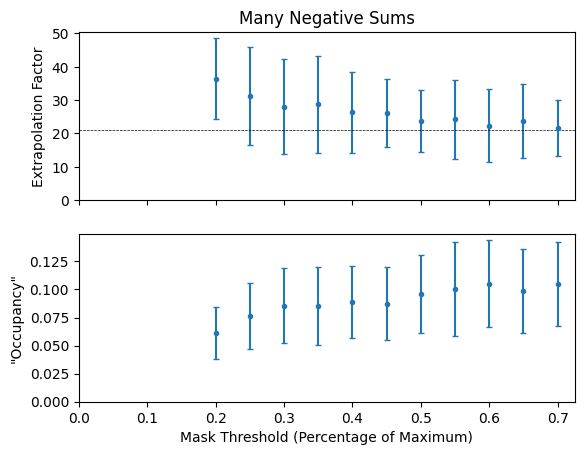

In [12]:
from meteorize import many_negsum

thresholds_many = np.arange(0.2, 0.75, 0.05)
from systematic_plots import calculate_many_negsum_best_guesses, plot_many_negsum_best_guesses
mns_best_guesses_dict = calculate_many_negsum_best_guesses(diffmap, map_xtrs, extrapolation_factors, thresholds_many, map_sampling)
plt.close('all')
%matplotlib inline
plot_many_negsum_best_guesses(mns_best_guesses_dict)

In [13]:
# thresholds_many
    # plt.ylim(0,80)
    # plt.ylim(0,0.5)


### Sidequest: Looking at the 'strongest' blobs - why are they different?

In [14]:
_, neg_blobs_restrict = find_largest_blobs(diffmap, map_sampling, threshold=0.4)
_, neg_blobs_huge = find_largest_blobs(diffmap, map_sampling, threshold=0.3)

# slice_3d(neg_blobs_huge, )

In [134]:

indices = np.unique(neg_blobs_huge[neg_blobs_restrict>0])
indices = indices[indices>0]  # remove background

biggest_blobs = np.zeros_like(neg_blobs_huge) 
for idx in indices:
    biggest_blobs[neg_blobs_huge == idx] = 1
# %matplotlib widget
# _ = slice_3d(biggest_blobs, )


In [135]:
mask_biggest_blobs = [neg_blobs_huge == idx for idx in indices if idx]
print(len(mask_biggest_blobs))
print(np.unique(biggest_blobs))
_, negsums, intersection_points = many_negsum(
    map_xtrs,
    extrapolation_factors,
    map_sampling=map_sampling,
    masks=mask_biggest_blobs,
    return_neg_sum=True,
    detailed=True,
)

55
[0 1]
Intersection Average: 26.32 ± 11.90
Intersection Average Inverse: 0.09 ± 0.03


In [ ]:
# # print(len(negsums))
# # fig, axs = plt.subplots(len(negsums), sharex=True, figsize=(10, 6))
# def calculate_many_negsum_all_lines(
#         diffmap,
#         map_xtrs,
#         extrapolation_factors,  
#         map_sampling=map_sampling,
# ):
#     colors = "red","orange", "yellow", "green", "blue", "purple"
#     thresholds = [0.35, 0.5]
#     processing_dicts = []
#     for jj, thresh in enumerate(thresholds):
#         _, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold=thresh)
#         neg_blobs_masks = [(neg_blobs == idx) for idx in np.unique(neg_blobs) if idx]
#         _, negsums, intersection_points = many_negsum(
#             map_xtrs,
#             extrapolation_factors,
#             map_sampling=map_sampling,
#             masks=neg_blobs_masks,
#             return_neg_sum=True,
#             detailed=True,
#         )
        
#         proccesing_dict = {
#         "threshold": thresh,
#         "extrapolation_factors": extrapolation_factors,
#         "negsums": negsums,
#         "intersection_points": intersection_points,
#         "neg_blobs_masks": neg_blobs_masks
#         }

#         processing_dicts.append(proccesing_dict)
#     return processing_dicts, thresholds, colors

processing_dicts, thresholds, colors = calculate_many_negsum_all_lines(
        diffmap,
        map_xtrs,
        extrapolation_factors,  
        map_sampling=map_sampling,
)


Intersection Average: 28.71 ± 14.48
Intersection Average Inverse: 0.09 ± 0.03
Intersection Average: 23.78 ± 9.22
Intersection Average Inverse: 0.10 ± 0.04


('red', 'orange', 'yellow', 'green', 'blue', 'purple')
('red', 'orange', 'yellow', 'green', 'blue', 'purple')


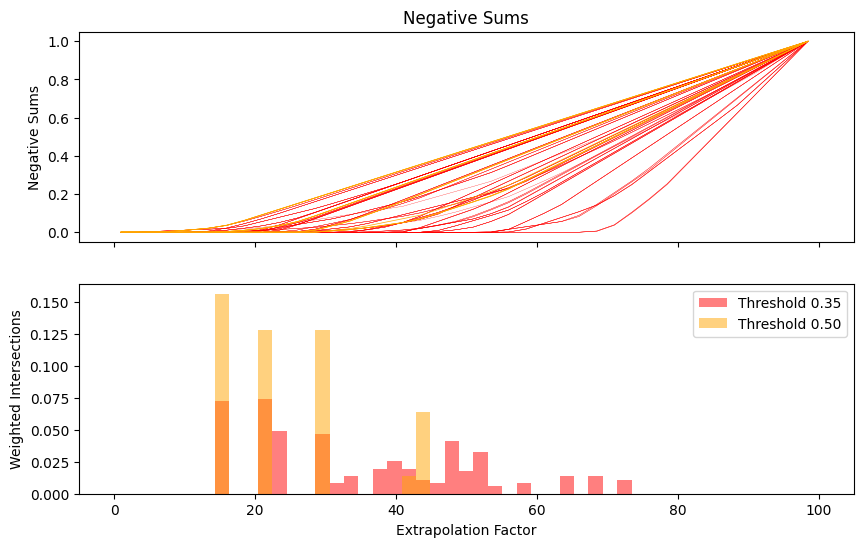

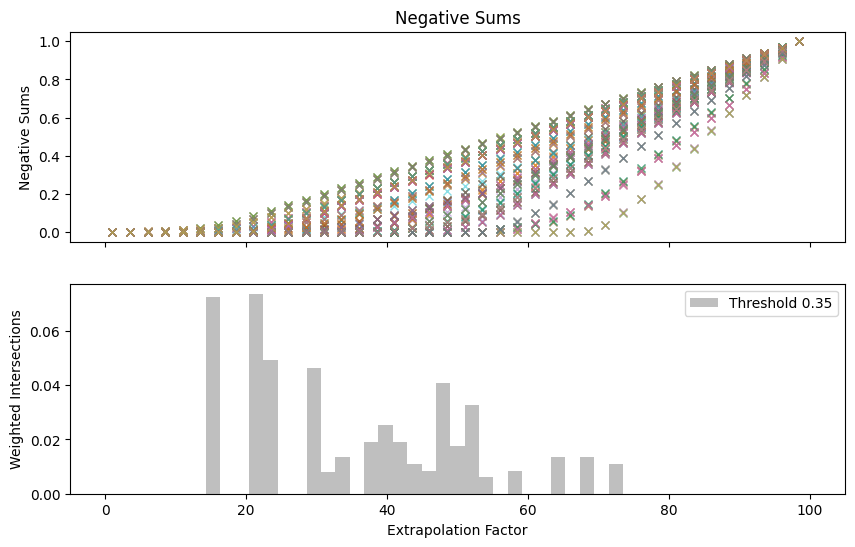

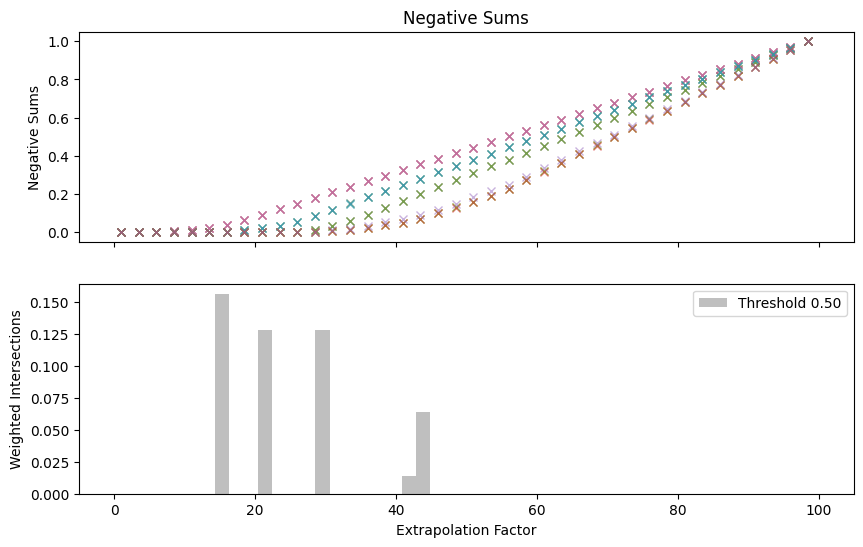

In [41]:
# fig, axs = plt.subplots(2, figsize=(10, 6), sharex=True)



plt.close('all')
%matplotlib inline
from systematic_plots import plot_many_negsum_all_lines, plot_many_negsum_all_lines_all_thresh
plot_many_negsum_all_lines_all_thresh(processing_dicts)

plot_many_negsum_all_lines(processing_dicts[0], )
plot_many_negsum_all_lines(processing_dicts[1], )

# Single Neg Sum, different Mask Thresholds

In [ ]:
from systematic_plots import calculate_single_nse

thresholds = np.arange(0.15, 0.8, 0.05)

    
negsums = calculate_single_nse( map_xtrs, extrapolation_factors, map_sampling, thresholds,)


running  0.15
running  0.2
running  0.25
running  0.30000000000000004
running  0.3500000000000001
running  0.4000000000000001
running  0.45000000000000007
running  0.5000000000000001
running  0.5500000000000002
running  0.6000000000000001
running  0.6500000000000001
running  0.7000000000000002
running  0.7500000000000002


<string>:23: RuntimeWarning: invalid value encountered in divide


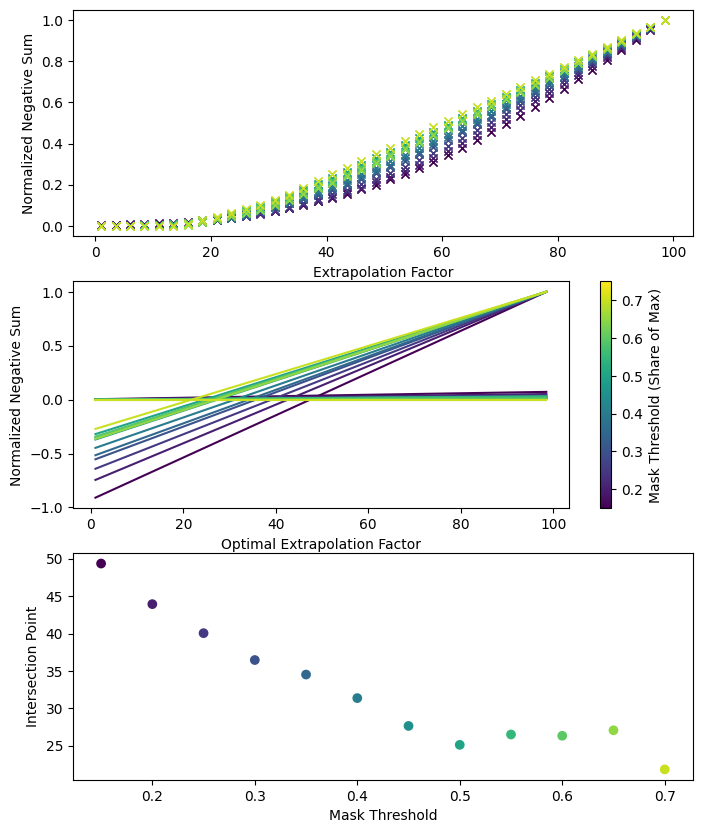

In [ ]:
from systematic_plots import plot_single_nse_overview
plot_single_nse_overview(extrapolation_factors, negsums, thresholds)

# Histogram Method

In [164]:
from systematic_plots import calculate_histogram_best_guess

thresholds = np.arange(0.15, 0.8, 0.05)
wassersteins =calculate_histogram_best_guess( diffmap, map_xtrs, map_dark, map_sampling, thresholds)

running  0.15
running  0.2
running  0.25
running  0.30000000000000004
running  0.3500000000000001
running  0.4000000000000001
running  0.45000000000000007
running  0.5000000000000001
running  0.5500000000000002
running  0.6000000000000001
running  0.6500000000000001
running  0.7000000000000002
running  0.7500000000000002


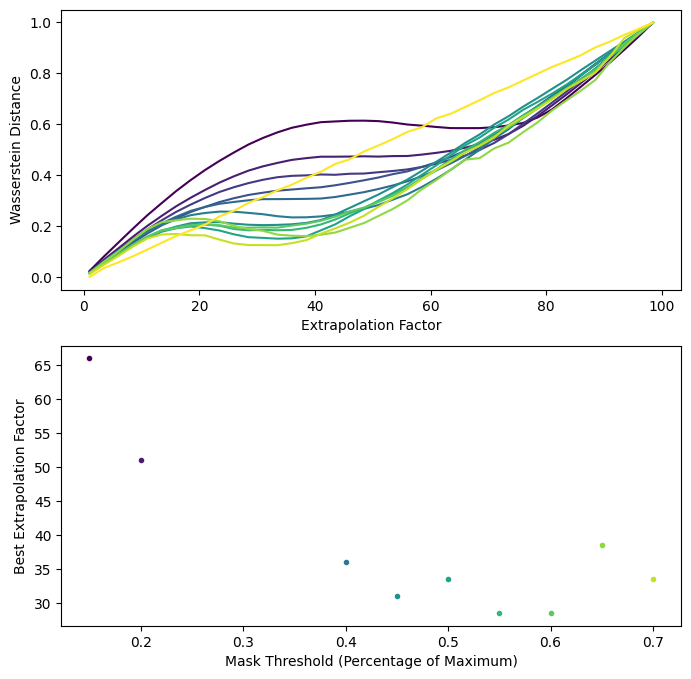

In [145]:
import matplotlib.cm as cm
import matplotlib.colors as colors

plt.close('all')
%matplotlib inline
from systematic_plots import plot_wasserstein_dists
plot_wasserstein_dists(extrapolation_factors, thresholds, wassersteins)


# PANDDA

In [ ]:
# plt.figure()
# plt.hist([np.sum(mask) for mask in neg_blobs_masks])
# intersection_of_blobs=np.zeros_like(neg_blobs)  # This line seems to be a placeholder, not needed
# for idx, mask in enumerate(neg_blobs_masks):
#     intersection_of_blobs[mask] = intersection_points[idx]
# from plotting3d import panels_3d
# _ = panels_3d([intersection_of_blobs, 40*masks["handpicked"]], imkwargs={'vmax':np.max(intersection_points), 'vmin':0})

In [127]:
delta_obj = diffmap.to_3d_numpy_map(map_sampling=map_sampling)

lax = 0.2
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold=lax)
mask_lax = np.logical_or(neg_blobs >0, pos_blobs>0)
mask_lax = masks["handpicked"]

strict = 0.5
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling, threshold=strict)
mask_strict = np.logical_or(neg_blobs >0, pos_blobs>0)

for mask in [mask_lax, mask_strict]:
    print(f"share of active pixel: {np.sum(mask)/mask.size:.3%}")

from meteorize import pandda
mean_local_strict, mean_global_strict = pandda(map_dark, map_xtrs, mask_strict, map_sampling)
mean_local_lax, mean_global_lax = pandda(map_dark, map_xtrs, mask_lax,map_sampling)
ml = [mean_local_strict, mean_local_lax]
mg = [mean_global_strict, mean_global_lax]
titles = ["high threshold mask", "TJ's handpicked mask"]


share of active pixel: 1.757%
share of active pixel: 0.011%


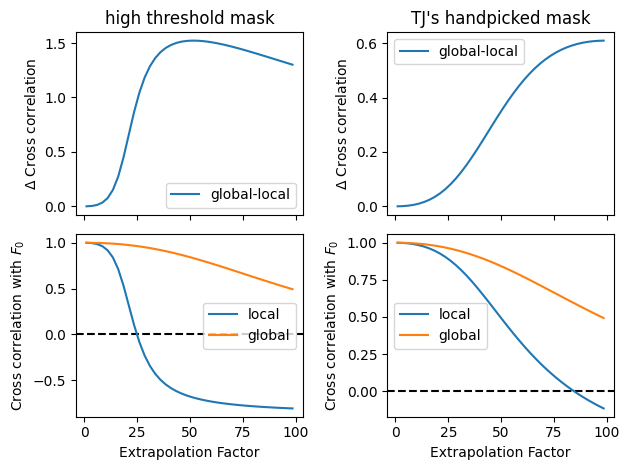

In [128]:

alpha_xtrs = extrapolation_factors
fig, axso = plt.subplots(2, 2, sharex=True, tight_layout=True)
for axs, mean_local, mean_global, title in zip(axso.T, ml, mg, titles):
    ax = axs[0]
    ax.set_title(title)
    ax.plot(alpha_xtrs, +mean_global - mean_local, label="global-local")
    ax.set_ylabel("$\\Delta$ Cross correlation")
    ax.legend()
    ax = axs[1]
    ax.axhline(0, c="k", linestyle="--")
    ax.plot(alpha_xtrs, mean_local, label="local")
    ax.plot(alpha_xtrs, mean_global, label="global")
    ax.set_xlabel("Extrapolation Factor")
    ax.set_ylabel("Cross correlation with $F_0$")
    ax.legend()



In [ ]:
# Other Stuff

In [ ]:
keyvals = np.unique(neg_blobs)
plt.figure()
plt.boxplot(intersections)
plt.show()
# plt.figure()
# plt.boxplot(weighted_size)
# plt.show()
plt.figure()
plt.boxplot(1/left_widths[1:])
plt.show()


In [ ]:
from scipy import stats

def get_fits2(neg_sum, alpha_invs, n_largest):
    a_sorted = np.argsort(alpha_invs)
    m_lowest = a_sorted <= n_largest
    m_biggest = a_sorted >= len(a_sorted) - n_largest
    res_lowest = stats.linregress(alpha_invs[m_lowest], neg_sum[m_lowest])
    res_biggest = stats.linregress(alpha_invs[m_biggest], neg_sum[m_biggest])
    np.linspace(np.min(alpha_invs), np.max(alpha_invs), 5)
    fit_lowest = res_lowest.intercept + res_lowest.slope * alpha_invs
    fit_biggest = res_biggest.intercept + res_biggest.slope * alpha_invs

    return fit_lowest, fit_biggest
fit_lowest2, fit_biggest2 = get_fits2(neg_sum2,extrapolation_factors, 3)
plt.figure()
ax = plt.gca()


neg_sum2 = -neg_sum_map
diff_low =  -(fit_lowest2-neg_sum2) #is still negative
diff_high = -(fit_biggest2-neg_sum2) #is still negative
smaller_diff = np.min([diff_low,diff_high],axis=0)
ax2 = ax.twinx()
ax.plot(extrapolation_factors, neg_sum2, 'x', label='neg sum')
ax.plot(extrapolation_factors,fit_lowest2)
ax.plot(extrapolation_factors,fit_biggest2)
ax2.plot(extrapolation_factors,smaller_diff/neg_sum2[np.argmax(smaller_diff)])
ax2.set_ylabel('Relative Difference ‰')
# area = np.simps(smaller_diff, extrapolation_factors)
area = np.trapz(smaller_diff, extrapolation_factors)
print("Integral of smaller_diff over extrapolation_factors:", area)



NameError: name 'neg_sum2' is not defined

In [ ]:
rho_xtrs = map_xtrs
def s2r(struc,hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(
        struc, high_resolution_limit=hs_limit
    )
    struc_vals = rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F", "PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.fftn(struc_vals_grid).real/struc_vals_grid.size
    return struc_vals_real

struc_light = gemmi.read_structure(pdbloc_light)
np.max(s2r(struc_light, hs_limit, 0) )
print(np.max(s2r(struc_light, hs_limit, 0) ))
print(np.max(rho_xtrs[7].to_3d_numpy_map(map_sampling=map_sampling) ))

# from photolyase import get_model_densities
# density_darkT, density_lightT = get_model_densities(pdbloc_dark, pdbloc_light, hs_limit)
image1 = s2r(struc_light, hs_limit, 0)
# from skimage.feature import match_template

1.4131175067909243
1.8568273


In [29]:
# density_light_ground = s2r(struc_light, hs_limit, 0)
# from skimage.feature import match_template
# cross_correl = []
# for ii in range(len(rho_xtrs)):
#     print(ii)
#     matched = match_template(density_light_ground , rho_xtrs[ii].to_3d_numpy_map(map_sampling=map_sampling))
#     if matched.size != 1:
#         print(matched)
#     cross_correl.append(matched[0][0])
   
from systematic_plots import crosscorrelation_groundtruth
cross_correls_all = crosscorrelation_groundtruth(pdbloc_light, map_xtrs, map_sampling=map_sampling, hs_limit=hs_limit)
cross_correls_ball = crosscorrelation_groundtruth(pdbloc_light, map_xtrs, map_sampling=map_sampling, hs_limit=hs_limit, mask=masks['ball'])
cross_correls_hand = crosscorrelation_groundtruth(pdbloc_light, map_xtrs, map_sampling=map_sampling, hs_limit=hs_limit, mask=masks['handpicked'])

Text(0, 0.5, 'Cross correlation with $F_1$')

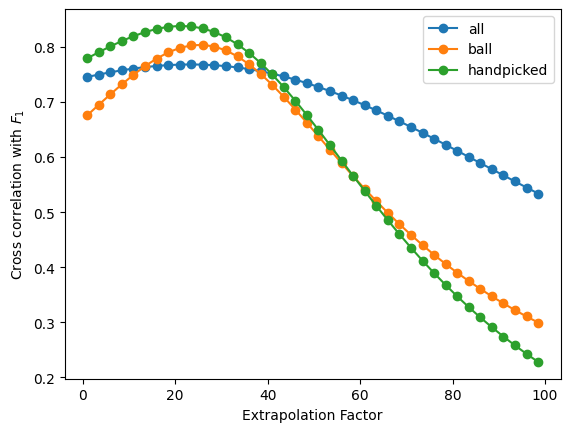

In [ ]:

fig, ax = plt.subplots()
ax.plot(extrapolation_factors, cross_correls_all, 'o-', label='all')
ax.plot(extrapolation_factors, cross_correls_ball, 'o-', label='ball')
ax.plot(extrapolation_factors, cross_correls_hand, 'o-', label='handpicked')
ax.legend()
ax.set_xlabel("Extrapolation Factor")
ax.set_ylabel("Cross correlation with $F_1$")


In [31]:
2/9

0.2222222222222222